# Adjoint methods, density and control of the heat equation

*Introduction to Control and Machine Learning · Part II: Optimization and long-time control · Notebook 07*

> **Central question.** *How can we compute gradients cheaply when the cost depends on the control through a state equation, and what changes when the state equation is a PDE?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 75–90 min · DEEPER LOOK and RESEARCH WINDOW ≈ 20 min more |
| **Execution time** | a few seconds (the finite-difference gradients of Laboratory 1 dominate) |
| **Exercises** | 6 exercises, ≈ 100–160 min |
| **Prerequisites** | [notebook 03](03_observability_duality_adjoints.ipynb) (duality, HUM, observability); [notebook 06](06_variational_principles_gradient_flows.ipynb) (direct method, gradient descent, Lagrange multipliers); the 3-point finite-difference Laplacian |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 53, 97, 141, 165, 189–200, 210–216, 234 (see the Source map at the end) |
| **Notation** | `notation.md` §§1, 10 (example E4). In §§1–3, as on the slides, the state is $x\in\mathbb R^N$ and the control is $b$. **In the PDE sections $x\in(0,1)$ is the spatial variable, $y$ the state and $u$ the control** (the slides write $f$ for the control) |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

> **First pass through this notebook.**
> *Essential:* the CORE sections §§1–5: the state–adjoint–gradient structure, density, heat control; Laboratories 1–2 (Figures 1–4); Exercises 1–2.
> *Deeper study:* the DEEPER LOOK §6 (existence for the density functional), Exercises 3–5.
> *Research-oriented:* the RESEARCH WINDOW §7 and the `ADVANCED` Exercise 6.

**Learning objectives.** After this notebook you should be able to

1. derive the adjoint method for a cost that depends on the control through a state equation, and count the solves it saves;
2. state and prove the density theorem: a dense range is approximated through a coercive functional built on the adjoint;
3. formulate null controllability of the heat equation, and obtain the control of minimal $L^2$ norm from an observability inequality;
4. explain why, for the heat equation, unique continuation does **not** imply observability, and what this means for computations;
5. compute approximate and null controls for a discretized heat equation, and explain where the computation is reliable and where it is not.

## Where are we?
`CORE`

> **Recap.** [Notebook 03](03_observability_duality_adjoints.ipynb): to steer $x'=Ax+Bu$, minimize the dual functional $J(\varphi_T)=\tfrac12\int_0^T|B^*\varphi|^2-\langle x^1,\varphi_T\rangle+\langle x^0,\varphi(0)\rangle$ over solutions of the adjoint system. Observability makes $J$ coercive, and the control is $u=B^*\hat\varphi$. In finite dimension, observability is equivalent to unique continuation. [Notebook 06](06_variational_principles_gradient_flows.ipynb): minimizers exist under continuity, convexity and coercivity, gradient descent finds them, and Lagrange multipliers are the seeds of adjoint states.

This notebook makes two moves. First, it turns the adjoint into a **computational method**: one extra solve gives the whole gradient of a cost that depends on the control through a state equation. Second, it takes the duality of notebook 03 to the **heat equation**, where it survives, but where the step "unique continuation ⇒ observability" breaks down.

## 1. Design through a state equation
`CORE`

In optimal shape design for aeronautics the cost (drag, lift, noise) depends on the shape $\Omega$ *not directly, but through the solution $u(\Omega)$ of the air dynamics around the airplane* (p. 165). The same structure appears in every control problem: the control acts on a state, and the cost measures the state.

The slides isolate the mechanism in the simplest setting (pp. 193–194). Let $A$ be an invertible $N\times N$ matrix, the state $x\in\mathbb R^N$ solve
$$
Ax=b ,
$$
where $b\in\mathbb R^N$ is the control, and let $x^*$ be a target. Of course $b=Ax^*$ would hit the target exactly. The aim is to understand how an optimal control *strategy* is implemented, so we minimize the compromise (p. 194)
$$
J(b)=\tfrac12|x-x^*|^2+\tfrac12|b|^2 ,\qquad x=A^{-1}b .
$$
By the direct method (notebook 06, §5) there is a unique minimizer $\bar b$: $J$ is continuous, strictly convex and coercive. It is characterized by the Euler–Lagrange equation
$$
J'(\bar b)\cdot c=(\bar x-x^*,\,y)+(\bar b,\,c)=0\qquad\text{for all }c\in\mathbb R^N,\qquad\text{where }Ay=c .
$$
Here $y$ is the **sensitivity** of the state in the direction $c$.

## 2. The adjoint method
`CORE`

**The cost of the naive approach (p. 195).** The optimality system above consists of $N$ equations, and writing it requires solving $Ay=c$ for every $c$ in a basis of $\mathbb R^N$: **$N$ solves**. The same happens at every step of a gradient-descent iteration, which needs $\nabla J(b)$. Finite differences, $\partial_iJ(b)\approx\big(J(b+he_i)-J(b)\big)/h$, also need $N+1$ solves, and they are only approximate.

**The adjoint state (pp. 195–196).** Introduce the solution $p$ of the **adjoint system**
$$
A^*p=x-x^* .
$$
The key observation is as simple as it is useful:
$$
(x-x^*,\,y)=(A^*p,\,y)=(p,\,Ay)=(p,\,c).
$$
Therefore
$$
\boxed{\;\nabla J(b)=p+b,\qquad Ax=b,\quad A^*p=x-x^* .\;}
$$
One state solve and one adjoint solve give the whole gradient, whatever $N$ is. *"And this reduces dramatically the computational cost"* (p. 196).

> **Remark on the source slides.** Pp. 194–196 write the identity at the minimizer $\bar b$. The computation holds at every $b$, which is what gradient descent needs. At the minimizer $\nabla J(\bar b)=0$ gives $\bar b=-\bar p$: **the optimal control is (minus) the adjoint state**, the same structure as $u=B^*\hat\varphi$ in notebook 03.

**Where the adjoint comes from** *(pedagogical addition)*. Treat $Ax=b$ as a constraint, with a Lagrange multiplier $p$ (notebook 06, §2):
$$
\mathscr L(b,x,p)=\tfrac12|x-x^*|^2+\tfrac12|b|^2-(p,\,Ax-b).
$$
Stationarity in $x$ gives $x-x^*-A^*p=0$, the adjoint equation. Stationarity in $b$ gives $b+p=0$. **The adjoint state is the Lagrange multiplier of the state equation.** For an evolution equation $x'=Ax+Bu$ with a terminal cost, the same computation produces the backward adjoint system $-\varphi'=A^*\varphi$ of notebook 03. The forward solve is then followed by one backward solve.

> **The state–adjoint–gradient structure.** One of the central patterns of the course.
>
> | | Algebraic model (§§1–2) | Evolution model (as in notebook 03) |
> |---|---|---|
> | **STATE**, forward | $Ax=b$ | $x'=Ax+Bu$, $x(0)=x^0$, solved forward in time |
> | **ADJOINT**, backward | $A^*p=x-x^*$ | $-\varphi'=A^*\varphi$, $\varphi(T)=x(T)-x^1$, solved backward in time |
> | **GRADIENT**, combination | $\nabla J(b)=p+b$ | $\nabla J(u)(t)=u(t)+B^*\varphi(t)$ |
>
> The cost on the right is $J(u)=\tfrac12|x(T)-x^1|^2+\tfrac12\int_0^T|u|^2\,dt$. The state is computed once forward, the adjoint once backward, its source is the derivative of the cost with respect to the state, and the gradient combines the adjoint with the explicit dependence of the cost on the control. The evolution column follows from the duality identity of notebook 03, exactly as $(x-x^*,y)=(p,c)$ followed from $A^*p=x-x^*$ here.

| Method | Solves of $A\,\cdot=\cdot$ or $A^*\cdot=\cdot$ per gradient | Exact? |
|---|---|---|
| Sensitivities $Ay=e_i$ | $1+N$ | yes |
| Forward finite differences | $1+N$ | no: error $O(h)$ plus rounding $O(\varepsilon_{\rm mach}/h)$ |
| Adjoint | $2$ | yes, up to rounding |

> **Predict.** For a tridiagonal $A$, one solve costs $O(N)$ operations. How do the running times of the adjoint gradient and of the finite-difference gradient grow with $N$? Which step $h$ makes the finite-difference gradient most accurate?

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import time
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import brentq

from src.pde_utils import heat_grid, dirichlet_laplacian, laplacian_eigen, indicator, heat_semigroup, heat_gramian_spectral
from src.plotting_utils import apply_style, COLORS

apply_style()
np.set_printoptions(precision=5, suppress=True)

**Laboratory 1: adjoint versus finite differences.** We take a steady convection–diffusion operator on $(0,1)$ with $N$ interior nodes, $A=-\Delta_h+c\,D_h$, where $D_h$ is the centred first difference and $c=20$. It is not symmetric, so the adjoint $A^*=A^\top$ really differs from $A$. The target is $x^*_i=\sin(\pi x_i)$, and we evaluate $\nabla J$ at $b=0$. Every solve is a sparse solve without reuse of factorizations. **The structural result is the solve count; running times depend on implementation and hardware.**

N =    50: solves adjoint 2, finite differences    51;  time 4.7e-04 s vs 1.7e-03 s;  relative difference 2.7e-05
N =   100: solves adjoint 2, finite differences   101;  time 1.6e-04 s vs 4.4e-03 s;  relative difference 2.7e-05
N =   200: solves adjoint 2, finite differences   201;  time 1.6e-04 s vs 1.2e-02 s;  relative difference 2.7e-05
N =   400: solves adjoint 2, finite differences   401;  time 2.2e-04 s vs 3.7e-02 s;  relative difference 2.6e-05
N =   800: solves adjoint 2, finite differences   801;  time 3.6e-04 s vs 1.3e-01 s;  relative difference 2.8e-05


N =  1600: solves adjoint 2, finite differences  1601;  time 7.8e-04 s vs 5.6e-01 s;  relative difference 3.0e-05
adjoint vs dense formula at a nonzero b: 1.0492590762104943e-16
directional derivative by the adjoint: 4.276492398584e-03
forward difference, relative error at h = 1e-1, 1e-3, 1e-5: 1.2e+01, 1.2e-01, 1.2e-03;  best 1.2e-05


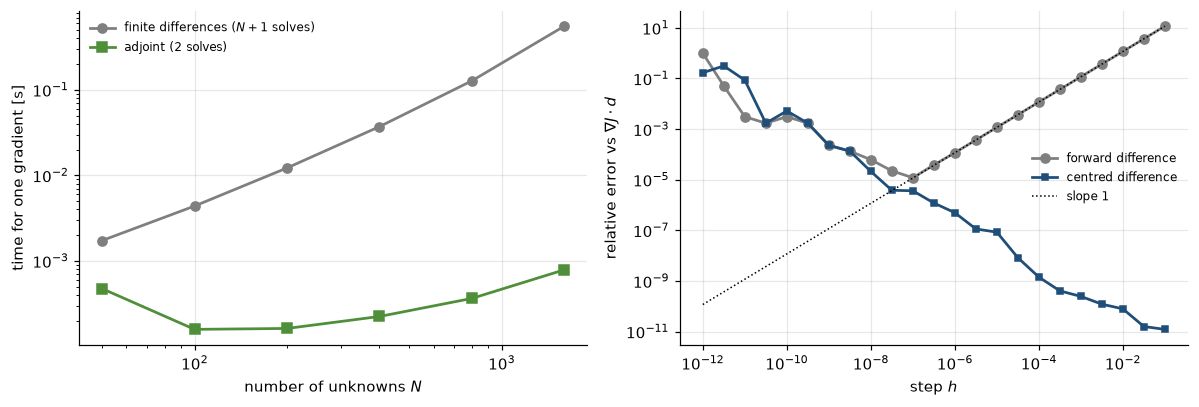

In [2]:
def convection_diffusion(N, c=20.0):
    h = 1.0 / (N + 1)
    off = np.ones(N - 1)
    D = sp.diags([-off, off], [-1, 1]) / (2 * h)
    return (-dirichlet_laplacian(N) + c * D).tocsc()


def cost(A, b, target):
    x = spla.spsolve(A, b)
    return 0.5 * np.sum((x - target) ** 2) + 0.5 * np.sum(b**2)


def gradient_adjoint(A, b, target):
    x = spla.spsolve(A, b)                                   # one state solve
    p = spla.spsolve(A.T.tocsc(), x - target)                # one adjoint solve
    return p + b


def gradient_fd(A, b, target, h=1e-6):
    J0, g = cost(A, b, target), np.empty_like(b)
    for i in range(len(b)):                                  # N more state solves
        e = np.zeros_like(b); e[i] = h
        g[i] = (cost(A, b + e, target) - J0) / h
    return g


sizes = [50, 100, 200, 400, 800, 1600]
t_adj, t_fd, rel_err = [], [], []
for N in sizes:
    A = convection_diffusion(N)
    target = np.sin(np.pi * heat_grid(N)[0])
    b = np.zeros(N)
    t0 = time.perf_counter(); g_adj = gradient_adjoint(A, b, target); t_adj.append(time.perf_counter() - t0)
    t0 = time.perf_counter(); g_fd = gradient_fd(A, b, target); t_fd.append(time.perf_counter() - t0)
    rel_err.append(np.linalg.norm(g_fd - g_adj) / np.linalg.norm(g_adj))
    print(f"N = {N:5d}: solves adjoint 2, finite differences {N + 1:5d};  time {t_adj[-1]:.1e} s vs {t_fd[-1]:.1e} s;  "
          f"relative difference {rel_err[-1]:.1e}")

# Independent check of the adjoint gradient by dense linear algebra (N = 200): grad J = A^{-T}(A^{-1} b - x*) + b.
A = convection_diffusion(200); target = np.sin(np.pi * heat_grid(200)[0]); b_test = 0.1 * np.cos(np.arange(200))
Ad = A.toarray()
g_dense = np.linalg.solve(Ad.T, np.linalg.solve(Ad, b_test) - target) + b_test
print("adjoint vs dense formula at a nonzero b:", np.linalg.norm(gradient_adjoint(A, b_test, target) - g_dense) / np.linalg.norm(g_dense))

# Directional gradient check at b_test: (J(b + h d) - J(b)) / h  ->  grad J . d  as h -> 0.
direction = np.sin(np.arange(200.0)); direction /= np.linalg.norm(direction)
g_ref = gradient_adjoint(A, b_test, target)
slope = g_ref @ direction
J_ref = cost(A, b_test, target)
steps = np.logspace(-12, -1, 23)
fwd_err = np.array([abs((cost(A, b_test + h * direction, target) - J_ref) / h - slope) for h in steps]) / abs(slope)
ctr_err = np.array([abs((cost(A, b_test + h * direction, target) - cost(A, b_test - h * direction, target)) / (2 * h) - slope)
                    for h in steps]) / abs(slope)
print(f"directional derivative by the adjoint: {slope:.12e}")
print(f"forward difference, relative error at h = 1e-1, 1e-3, 1e-5: {fwd_err[-1]:.1e}, {fwd_err[np.argmin(abs(steps - 1e-3))]:.1e}, "
      f"{fwd_err[np.argmin(abs(steps - 1e-5))]:.1e};  best {fwd_err.min():.1e}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.loglog(sizes, t_fd, "o-", color=COLORS["reference"], label="finite differences ($N+1$ solves)")
ax1.loglog(sizes, t_adj, "s-", color=COLORS["adjoint"], label="adjoint (2 solves)")
ax1.set_xlabel("number of unknowns $N$"); ax1.set_ylabel("time for one gradient [s]"); ax1.legend(fontsize=8)
ax2.loglog(steps, fwd_err, "o-", color=COLORS["reference"], label="forward difference")
ax2.loglog(steps, ctr_err, "s-", color=COLORS["state"], ms=4, label="centred difference")
ax2.loglog(steps, fwd_err[-1] * steps / steps[-1], ":", color="black", lw=1, label="slope 1")
ax2.set_xlabel("step $h$"); ax2.set_ylabel(r"relative error vs $\nabla J\cdot d$"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 1.** Gradient of $J(b)=\tfrac12|x-x^*|^2+\tfrac12|b|^2$ for the convection–diffusion operator. *Left:* running time of one full gradient against $N$ (log–log; wall-clock times on the machine that executed the notebook). *Right:* the **gradient check** for $N=200$: relative error of forward and centred difference quotients of $J$ in a fixed unit direction $d$, against the adjoint directional derivative $\nabla J\cdot d$, as functions of the step $h$.

*Interpretation (answer to the prediction).* The structural message: one gradient costs **$2$ solves by the adjoint method and $N+1$ by finite differences**. The machine-dependent times only illustrate it: the finite-difference time grows by about $4$ per doubling of $N$, while the adjoint time is dominated by overheads. On the right, the forward-difference error **decreases like $h$** (dotted slope-1 line) until about $h\approx10^{-7}$, where rounding errors of size $\varepsilon_{\rm mach}/h$ take over. This first-order decrease is the test that the adjoint gradient is correct; a wrong gradient would make the error level off at a fixed value instead. The centred difference is exact for this quadratic cost, so only its rounding error is visible. The adjoint gradient is the exact derivative of the discrete cost, up to rounding, and it agrees with an independent dense computation to about $10^{-15}$.

### Control ↔ ML: the adjoint method and reverse-mode differentiation
`CORE` · **DIRECT CONNECTION**

Training a network means computing the gradient of a loss with respect to many parameters, through a chain of layers. The slides record that **backpropagation (1974) is equivalent to the chain rule and automatic differentiation in reverse accumulation mode** (Werbos, p. 53). The correspondence with the box above is precise. The **forward pass** propagates the state through the layers. The **backward pass** propagates the adjoint, the sensitivity of the loss, through the transposed layer maps. The **gradient** with respect to every parameter combines the two, at the cost of about one extra pass, whatever the number of parameters.

For a computation written as a finite sequence of steps, reverse-mode differentiation *is* the discrete adjoint of that sequence. In continuous-time models one must still choose between differentiating the continuous problem and then discretizing the adjoint, or discretizing first and differentiating the discrete steps. The two adjoints need not coincide. Exercise 6 is a first instance of the discrete adjoint; [notebook 13](13_resnets_neural_odes.ipynb) reads a residual network as a controlled ODE.

## 3. Density: approximating what cannot be reached exactly
`CORE`

Let $H$ be a Hilbert space and $\mathcal L:H\to H$ a bounded linear operator **with dense range**. Then for every $f\in H$ and every $\varepsilon>0$ there is $u\in H$ with (p. 189)
$$
\|\mathcal Lu-f\|_H\le\varepsilon .
\tag{D}
$$
The range is often dense without $\mathcal L$ being surjective. This happens for time-irreversible evolutions, such as the heat equation, and it is relevant in control: the system can be steered to a dense set of targets, but not to all of them (p. 189). The slides' example is the **Gaussian filter** $\mathcal Lu=G*u$, $G(x)=(4\pi)^{-N/2}e^{-|x|^2/4}$ (pp. 141, 189). This is the solution at time $1$ of the heat equation with initial datum $u$. Its outputs are extremely smooth, so a discontinuous $f$ is never exactly $\mathcal Lu$, yet it can be approximated.

**Dense range ⟺ injective adjoint.** By the Hahn–Banach theorem, the range of $\mathcal L$ is dense if and only if $\mathcal L^*$ is injective: $\mathcal L^*v=0$ implies $v=0$ (p. 189). In finite dimension this is the identity $(\operatorname{Range}\mathcal L)^\perp=\ker \mathcal L^*$ (Exercise 3).

**A constructive method (p. 190).** In practice we need an algorithm to build $u$. Consider
$$
J_\varepsilon(v)=\tfrac12\|\mathcal L^*v\|_H^2+\varepsilon\|v\|_H-(f,v)_H .
$$
Both $f$ and $\varepsilon$ enter its definition.

> **Theorem 1 (density by minimization; pp. 190–191).**
> *Assumption:* $\mathcal L^*$ is injective.
> *Conclusion:* $J_\varepsilon$ has a minimizer $\tilde v$, and $u=\mathcal L^*\tilde v$ satisfies $\|\mathcal Lu-f\|_H\le\varepsilon$.
> *Interpretation:* the approximate control is the image under $\mathcal L^*$ of the minimizer, exactly as the HUM control was $B^*\hat\varphi$.

*Proof that the minimizer gives (D) (p. 190).* For any $v$ and $\delta>0$, $J_\varepsilon(\tilde v\pm\delta v)-J_\varepsilon(\tilde v)\ge0$. The norm term changes by at most $\varepsilon\delta\|v\|$, by the triangle inequality. Keeping the terms of order $\delta$ and letting $\delta\to0$ gives
$$
\big|(\mathcal L^*\tilde v,\mathcal L^*v)-(f,v)\big|\le\varepsilon\|v\|,\quad\text{that is,}\quad\big|(\mathcal L\mathcal L^*\tilde v-f,\,v)\big|\le\varepsilon\|v\|\quad\text{for all }v,
$$
so $\|\mathcal L\mathcal L^*\tilde v-f\|\le\varepsilon$. $\square$

*Existence (p. 191).* $J_\varepsilon$ is continuous and convex, so by the direct method (notebook 06, DEEPER LOOK §11) it suffices to prove coercivity. Under injectivity alone, coercivity rests on weak compactness: the proof is in the DEEPER LOOK §6.

**Why the term $\varepsilon\|v\|$ is needed (p. 190).** If we had $\|\mathcal L^*v\|^2\ge\alpha\|v\|^2$, $J$ would be coercive even for $\varepsilon=0$, and $\mathcal L$ would be onto. Injectivity alone does not guarantee that inequality (an injective operator may or may not be bounded below), and when it fails the $\varepsilon$-term provides coercivity. **Injectivity is qualitative; the inequality is quantitative.** This is the distinction between unique continuation and observability, which will decide the fate of the heat equation in §4.

**How to compute the minimizer** *(pedagogical addition)*. The norm $\|v\|$ is differentiable at every $v\ne0$ but not at $v=0$. If $\tilde v\ne0$, the minimizer satisfies $\mathcal L\mathcal L^*\tilde v+\varepsilon\,\tilde v/\|\tilde v\|=f$. Writing $\mu=\varepsilon/\|\tilde v\|$, this is $\tilde v=(\mathcal L\mathcal L^*+\mu I)^{-1}f$, and $\mu$ is fixed by the condition $\|\mathcal L\mathcal L^*\tilde v-f\|=\mu\|\tilde v\|=\varepsilon$. The residual is an increasing function of $\mu$, so one scalar root-finding gives $\mu$. $J_\varepsilon$ is strictly convex ($\mathcal L^*$ is injective), so $\tilde v$ is unique. If $\|f\|>\varepsilon$, then $\tilde v\ne0$ (for $\tilde v=0$ the inequality above reads $|(f,v)|\le\varepsilon\|v\|$, i.e. $\|f\|\le\varepsilon$), and the residual equals $\varepsilon$ *exactly*. If $\|f\|\le\varepsilon$, then $J_\varepsilon(v)\ge(\varepsilon-\|f\|)\|v\|\ge0=J_\varepsilon(0)$, so $u=0$ and the residual is $\|f\|\le\varepsilon$.

> **Predict.** Let $\mathcal L$ be the heat semigroup at a small time $\tau$ on $(0,1)$, and compare two targets: a "hat" function with three kinks, which is not in the range of $\mathcal L$, and $f=\mathcal Lg_0$ for a smooth bump $g_0$. How does $\|u_\varepsilon\|$ behave as $\varepsilon\to0$ in each case?

unreachable part of the hat beyond 400 modes, relative: 3.8e-04
eps = 1e-01 x ||f||:  ||u_eps|| for the hat = 3.065e-01;  for f = L g0: 0.2843  (bound 2||g0|| = 0.6333)
eps = 3e-02 x ||f||:  ||u_eps|| for the hat = 3.391e-01;  for f = L g0: 0.3069  (bound 2||g0|| = 0.6333)
eps = 1e-02 x ||f||:  ||u_eps|| for the hat = 2.511e+01;  for f = L g0: 0.3134  (bound 2||g0|| = 0.6333)
eps = 5e-03 x ||f||:  ||u_eps|| for the hat = 4.799e+07;  for f = L g0: 0.3150  (bound 2||g0|| = 0.6333)
eps = 3e-03 x ||f||:  ||u_eps|| for the hat = 3.954e+17;  for f = L g0: 0.3157  (bound 2||g0|| = 0.6333)


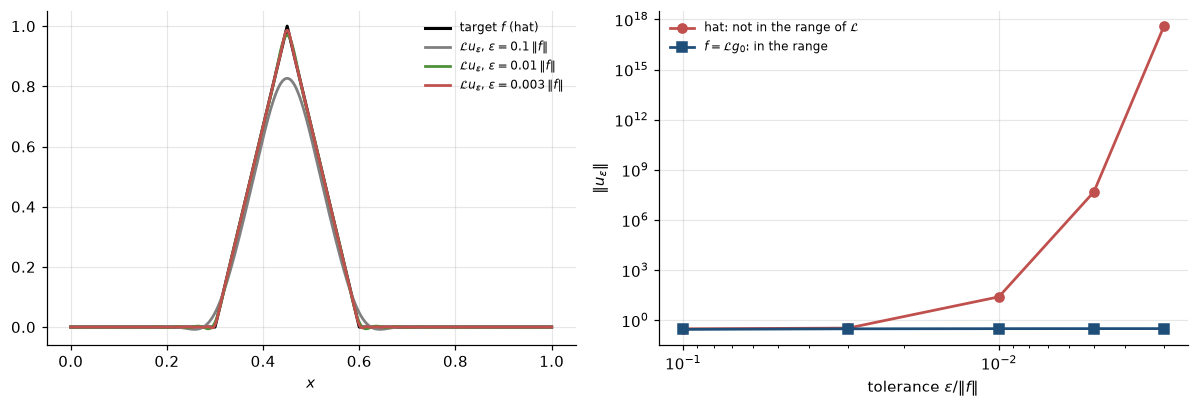

In [3]:
# The heat semigroup at time tau on (0,1) with Dirichlet conditions, in the exact sine basis:
# L e_j = exp(-(j pi)^2 tau) e_j, e_j(x) = sqrt(2) sin(j pi x). We keep J_modes modes; the exact
# coefficients of the target beyond them are counted in the residual (they cannot be reached).
tau, J_modes = 5e-4, 400
j = np.arange(1, J_modes + 1)
sigma = np.exp(-(j * np.pi) ** 2 * tau)

c_hat, w_hat = 0.45, 0.15                                  # hat f = max(0, 1 - |x - c|/w), exact coefficients
a_j = j * np.pi
hat_coeffs = -np.sqrt(2) / (a_j**2 * w_hat) * (np.sin(a_j * (c_hat - w_hat)) - 2 * np.sin(a_j * c_hat) + np.sin(a_j * (c_hat + w_hat)))
hat_norm = np.sqrt(2 * w_hat / 3)
hat_tail = np.sqrt(max(hat_norm**2 - np.sum(hat_coeffs**2), 0.0))

x_fine = np.linspace(0, 1, 4001)
basis = np.sqrt(2) * np.sin(np.outer(x_fine, j) * np.pi)
g0 = np.exp(-((x_fine - 0.45) / 0.08) ** 2)                # smooth bump; f = L g0 lies in the range
g0_coeffs = np.trapezoid(basis * g0[:, None], x_fine, axis=0)
range_coeffs = sigma * g0_coeffs


def density_control(coeffs, eps, tail=0.0):
    # Minimizer of J_eps: v = (L L* + mu)^{-1} f with ||L L* v - f|| = eps; returns the coefficients of u = L* v.
    residual = lambda log_mu: np.sqrt(np.sum((np.exp(log_mu) / (sigma**2 + np.exp(log_mu)) * coeffs) ** 2) + tail**2) - eps
    if np.sqrt(np.sum(coeffs**2) + tail**2) <= eps:
        return np.zeros_like(coeffs)
    mu = np.exp(brentq(residual, -740, 30, xtol=1e-14))
    return sigma * coeffs / (sigma**2 + mu)


eps_rel = [1e-1, 3e-2, 1e-2, 5e-3, 3e-3]
norms_hat = [np.linalg.norm(density_control(hat_coeffs, e * hat_norm, hat_tail)) for e in eps_rel]
norms_range = [np.linalg.norm(density_control(range_coeffs, e * np.linalg.norm(range_coeffs))) for e in eps_rel]
print("unreachable part of the hat beyond", J_modes, "modes, relative:", f"{hat_tail / hat_norm:.1e}")
for e, n1, n2 in zip(eps_rel, norms_hat, norms_range):
    print(f"eps = {e:5.0e} x ||f||:  ||u_eps|| for the hat = {n1:.3e};  for f = L g0: {n2:.4f}  (bound 2||g0|| = {2 * np.sqrt(np.sum(g0_coeffs**2)):.4f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.plot(x_fine, np.maximum(0, 1 - np.abs(x_fine - c_hat) / w_hat), color="black", lw=2, label="target $f$ (hat)")
for e, color in zip((1e-1, 1e-2, 3e-3), (COLORS["reference"], COLORS["adjoint"], COLORS["control"])):
    u_coeffs = density_control(hat_coeffs, e * hat_norm, hat_tail)
    ax1.plot(x_fine, basis @ (sigma * u_coeffs), color=color, label=rf"$\mathcal{{L}}u_\varepsilon$, $\varepsilon={e:g}\,\|f\|$")
ax1.set_xlabel("$x$"); ax1.legend(fontsize=8)
ax2.loglog(eps_rel, norms_hat, "o-", color=COLORS["control"], label=r"hat: not in the range of $\mathcal{L}$")
ax2.loglog(eps_rel, norms_range, "s-", color=COLORS["state"], label=r"$f=\mathcal{L}g_0$: in the range")
ax2.invert_xaxis(); ax2.set_xlabel(r"tolerance $\varepsilon/\|f\|$"); ax2.set_ylabel(r"$\|u_\varepsilon\|$"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 2.** Density for the heat semigroup $\mathcal L$ at time $\tau=5\cdot10^{-4}$ on $(0,1)$, computed in the exact sine basis with 400 modes. The coefficients of the target beyond these modes are counted in the residual. *Left:* the hat target and $\mathcal Lu_\varepsilon$ for three tolerances. *Right:* the norm of the control $u_\varepsilon$ against the tolerance, for the hat and for a target $f=\mathcal Lg_0$ in the range.

*Interpretation (answer to the prediction).* Every tolerance used is below $\|f\|$, so the residual is exactly $\varepsilon$. For $f=\mathcal Lg_0$ the norm stays below $2\|g_0\|$ for every $\varepsilon$. Indeed $J_\varepsilon(\tilde v)\le J_\varepsilon(0)=0$ gives $\tfrac12\|\mathcal L^*\tilde v\|^2\le(\mathcal Lg_0,\tilde v)=(g_0,\mathcal L^*\tilde v)\le\|g_0\|\,\|\mathcal L^*\tilde v\|$. For the hat, $\|u_\varepsilon\|$ explodes: it is about $25$ at $\varepsilon=10^{-2}\|f\|$ and astronomically large at $3\cdot10^{-3}\|f\|$. Approximating a target outside the range requires the high modes, which the filter damps like $e^{-(j\pi)^2\tau}$, and the control must undo that damping. **Dense range gives every tolerance, but not at a bounded cost.**

## 4. Control of the heat equation
`CORE`

Let $\Omega\subset\mathbb R^n$ be a bounded, connected open set with $C^2$ boundary, $\omega\subset\Omega$ a nonempty open subset where the control acts, and $1_\omega$ its characteristic function. The controlled heat equation is (p. 213)
$$
\begin{cases}
y_t-\Delta y=u\,1_\omega & \text{in }\Omega\times(0,T),\\
y=0 & \text{on }\partial\Omega\times(0,T),\\
y(x,0)=y^0(x) & \text{in }\Omega,
\end{cases}
$$
with $y^0\in L^2(\Omega)$ and $u\in L^2(\omega\times(0,T))$. The heat equation is time-irreversible and smoothing, so the set of states reachable at time $T$ is dense in $L^2(\Omega)$ (approximate controllability) but is not all of $L^2(\Omega)$: exact controllability to arbitrary $L^2$ targets fails. The notion studied here is **null controllability**: steer the state to $y(T)=0$.

> **Theorem 2 (null controllability; Fursikov–Imanuvilov, Lebeau–Robbiano; p. 214, cited without proof).**
> *Assumptions:* $\Omega$ bounded, connected, with $C^2$ boundary; $\omega\subset\Omega$ nonempty and open; $T>0$; data $y^0\in L^2(\Omega)$, controls in $L^2(\omega\times(0,T))$.
> *Conclusion:* for every such $T$, $\omega$ and $y^0$ there is a control $u\in L^2(\omega\times(0,T))$ with $y(T)=0$.
> *Interpretation:* heat can be steered to rest in arbitrarily short time, from an arbitrarily small region. The proofs rely on Carleman inequalities, which are beyond this course.

**HUM for the heat equation (pp. 214–215).** Exactly as in notebook 03, the control of minimal $L^2$ norm is obtained by minimizing
$$
J_0(\varphi_T)=\frac12\int_0^T\!\!\int_\omega\varphi^2\,dx\,dt+\int_\Omega\varphi(x,0)\,y^0(x)\,dx
$$
over the solutions of the adjoint heat equation, which runs backward in time:
$$
-\varphi_t-\Delta\varphi=0\ \text{ in }\Omega\times(0,T),\qquad\varphi=0\ \text{ on }\partial\Omega\times(0,T),\qquad\varphi(x,T)=\varphi_T(x).
$$
$J_0$ is continuous and convex. It is coercive because of the **observability inequality**
$$
\|\varphi(\cdot,0)\|_{L^2(\Omega)}^2\le C\int_0^T\!\!\int_\omega\varphi^2\,dx\,dt\qquad\text{for all }\varphi_T,
\tag{O}
$$
which is the initial-form inequality of notebook 03, with $c_0=1/C$. If $\bar\varphi$ is the adjoint solution associated with the minimizer, the control is
$$
u=\bar\varphi\,1_\omega ,
$$
the observation of the optimal adjoint (p. 215).

> **Remark on the source slides.** P. 214 says that $J_0$ is coercive "from $L^2(\Omega)$ to $\mathbb R$" because of (O). Inequality (O) bounds $\varphi(0)$, not $\varphi_T$, by the observed quantity. It gives coercivity with respect to the norm $\big(\int_0^T\!\int_\omega\varphi^2\big)^{1/2}$, which is strictly weaker than the $L^2(\Omega)$-norm of $\varphi_T$ (see below). The minimizer therefore exists in the completion of $L^2(\Omega)$ for that norm, which is the standard framework. The control $u=\bar\varphi 1_\omega$ is still in $L^2$. The slides also write $\varphi^0$ for the terminal datum and $f$ for the control; we write $\varphi_T$ and $u$ (`notation.md`).

**How the control is distributed in time (pp. 212, 215–216).** Three things must be kept apart.
- *The slides' observation.* The slides observe that the control tends to concentrate its action near $t=T$, and relate this to the structure of the optimality system,
$$
y_t-\Delta y=\varphi 1_\omega,\quad y(0)=y^0,\quad y(T)=0;\qquad-\varphi_t-\Delta\varphi=0,
$$
in which the adjoint appears isolated, as the solution of its own backward equation, with no coupling back from the state.
- *What the backward equation suggests.* Run backward from $t=T$, the adjoint damps its high frequencies, so $\bar\varphi$ can be large and oscillatory near $t=T$ and smoother at earlier times. This is a heuristic. It does not by itself imply that $\|\bar\varphi(t)\|_{L^2(\omega)}$ is monotone in $t$, nor that the action concentrates at $t=T$ for every horizon.
- *What our examples show.* In the regularized ($\varepsilon$) controls of Figure 4, the action concentrates near $t=T$ for $T=0.5$ and $T=1$, but not for the short horizon $T=0.1$, where the control acts during the whole interval and decreases towards the end.

Theorem 2 says nothing about the time profile of the control. Notebook 08 shows how a cost on the state changes the optimality system.

### Unique continuation does not imply observability
`CORE`

In notebook 03 (p. 97) the observability inequality was *equivalent* to unique continuation, $B^*\varphi\equiv0\Rightarrow\varphi_T=0$. The proof used the compactness of the unit sphere of $\mathbb R^n$. *"Unfortunately the equivalence is not true for infinite-dimensional systems"* (p. 97). The heat equation shows both halves of the story. We use the 1-D case $\Omega=(0,1)$, where the eigenfunctions of $-\partial_{xx}$ are $e_j(x)=\sqrt2\sin(j\pi x)$, with eigenvalues $\lambda_j=(j\pi)^2$ *(pedagogical addition)*.

**Unique continuation holds.** Write $\varphi(x,t)=\sum_ja_je^{-\lambda_j(T-t)}e_j(x)$. If $\varphi=0$ on $\omega\times(0,T)$, then for each $x\in\omega$ the Dirichlet series $s\mapsto\sum_ja_je_j(x)e^{-\lambda_js}$ vanishes for $s\in(0,T)$. It is analytic in $s>0$, so it vanishes for all $s>0$. Multiplying by $e^{\lambda_1s}$ and letting $s\to\infty$ gives $a_1e_1(x)=0$, and inductively $a_je_j(x)=0$ for all $j$ and all $x\in\omega$. Hence $a_j=0$ and $\varphi_T=0$. By §3, the control-to-state map has a dense range: the heat equation is **approximately controllable**.

**Observability of the terminal datum fails.** Take $\varphi_T=e_j$. Then $\varphi=e^{-\lambda_j(T-t)}e_j$, and
$$
\int_0^T\!\!\int_\omega\varphi^2\le\int_0^Te^{-2\lambda_j(T-t)}dt\le\frac1{2\lambda_j}\ \longrightarrow\ 0,
\qquad\text{while}\qquad\|\varphi_T\|=1 .
$$
No inequality $\|\varphi_T\|^2\le C\int\!\int_\omega\varphi^2$ can hold. **The terminal observability constant is $c_{\rm term}=0$.** This is why exact controllability to arbitrary targets fails. The inequality (O) that does hold bounds only $\varphi(0)=e^{-\lambda_jT}e_j$, which is exponentially small for high modes. That (O) holds at all, with a constant uniform over all $\varphi_T$, is the deep part of Theorem 2. Unique continuation alone does not give it.

**Qualitative versus quantitative: a summary.** Let $\mathcal L:L^2(\omega\times(0,T))\to L^2(\Omega)$, $u\mapsto y(T)$ with $y^0=0$, be the control-to-final-state map. Its adjoint is $\mathcal L^*\varphi_T=\varphi\,1_\omega$, by the duality identity of notebook 03. The results of §3 apply verbatim to an operator between two different Hilbert spaces.

| Type | Property of $\mathcal L^*$ | Consequence for the range of $\mathcal L$ | Controllability | Heat equation |
|---|---|---|---|---|
| qualitative | $\mathcal L^*\varphi_T=0\Rightarrow\varphi_T=0$ (unique continuation) | $\overline{\operatorname{Range}\mathcal L}=L^2(\Omega)$ (dense) | approximate | holds |
| quantitative, partial | $\|\varphi(0)\|\le\sqrt C\,\|\mathcal L^*\varphi_T\|$, inequality (O) | $\operatorname{Range}\mathcal L\supseteq\operatorname{Range}e^{T\Delta}$ | null | holds (Theorem 2) |
| quantitative, full | $\|\mathcal L^*\varphi_T\|\ge c\,\|\varphi_T\|$ (coercivity) | $\operatorname{Range}\mathcal L=L^2(\Omega)$ (onto) | exact | fails ($c_{\rm term}=0$) |

Each row implies the one above it. The second row's equivalence between (O) and the range inclusion is a standard duality lemma, stated here without proof. In finite dimension the three rows coincide (notebook 03, p. 97). For the heat equation they are three different properties, and the injectivity of the first row does **not** by itself provide the inequality of the second.

**What (O) buys: bounded controls** *(pedagogical addition)*. Combine the density method of §3 with the heat equation. Minimize
$$
J_\varepsilon(\varphi_T)=\tfrac12\int_0^T\!\!\int_\omega\varphi^2+\varepsilon\|\varphi_T\|+\int_\Omega\varphi(0)\,y^0 .
$$
By Theorem 1, applied with $\mathcal L$ the control-to-state map and $f=-e^{T\Delta}y^0$, the control $u_\varepsilon=\varphi_\varepsilon1_\omega$ gives $\|y(T)\|\le\varepsilon$. And since $J_\varepsilon(\varphi_\varepsilon)\le J_\varepsilon(0)=0$, (O) gives
$$
\tfrac12\|u_\varepsilon\|^2\le-\int_\Omega\varphi_\varepsilon(0)y^0\le\sqrt C\,\|y^0\|\,\|u_\varepsilon\|,\qquad\text{so}\qquad\|u_\varepsilon\|_{L^2(\omega\times(0,T))}\le2\sqrt C\,\|y^0\| ,
$$
**uniformly in $\varepsilon$**. A weak limit as $\varepsilon\to0$ is a null control. Without (O), as for the hat target of Figure 2, the controls exist for each $\varepsilon$ but their norms may blow up.

**Laboratory 2: the heat equation E4.** We discretize $\Omega=(0,1)$ with $N_x$ interior nodes and the Dirichlet Laplacian $\Delta_h$, with control region $\omega=(0.2,0.5)$, horizon $T=0.1$ and initial state $y^0=1_{(0.6,0.9)}$, which lies outside $\omega$. The semi-discrete system $y'=\Delta_hy+1_\omega u$ is solved **exactly in time**, through the eigenpairs of $\Delta_h$. Its Gramian is computed in closed form in that basis, without quadrature. All norms are discrete $L^2$ norms, $\|v\|_h^2=h\sum_iv_i^2$ for the state and $\int_0^T\|u(t)\|_h^2dt$ for the control.

We first look at the Gramian $\mathcal G_T$, which would give the exact discrete null control through $\mathcal G_T\varphi_T=-e^{T\Delta_h}y^0$, as in notebook 03. Then we compute the $\varepsilon$-controls of the functional $J_\varepsilon$ above, for several tolerances and meshes.

> **Predict.** As $N_x$ grows, what happens to $\lambda_{\min}(\mathcal G_T)$? Can we trust a direct solve of $\mathcal G_T\varphi_T=d$ for $N_x=50$? And how should $\|u_\varepsilon\|$ behave as $\varepsilon\to0$, if the discrete problems inherit (O)?

computed lambda_min, lambda_max of G_T: {6: ('7.4e-07', '2.3e-02'), 8: ('2.0e-08', '2.4e-02'), 10: ('5.3e-10', '2.2e-02'), 12: ('1.5e-11', '2.3e-02'), 14: ('3.9e-13', '2.1e-02'), 16: ('1.1e-14', '2.2e-02'), 20: ('8.3e-18', '2.2e-02'), 30: ('-9.7e-21', '2.2e-02'), 50: ('-1.6e-20', '2.2e-02')}
N_x =  20: ||u_eps|| = [1.2116 1.843  2.1789 2.3884];  attained |y(T)| / eps = [1. 1. 1. 1.]
N_x =  40: ||u_eps|| = [1.2003 1.8125 2.1262 2.3126];  attained |y(T)| / eps = [1. 1. 1. 1.]


N_x =  80: ||u_eps|| = [1.1979 1.8055 2.1142 2.2948];  attained |y(T)| / eps = [1. 1. 1. 1.]
N_x = 160: ||u_eps|| = [1.1975 1.8042 2.112  2.2913];  attained |y(T)| / eps = [1. 1. 1. 1.]


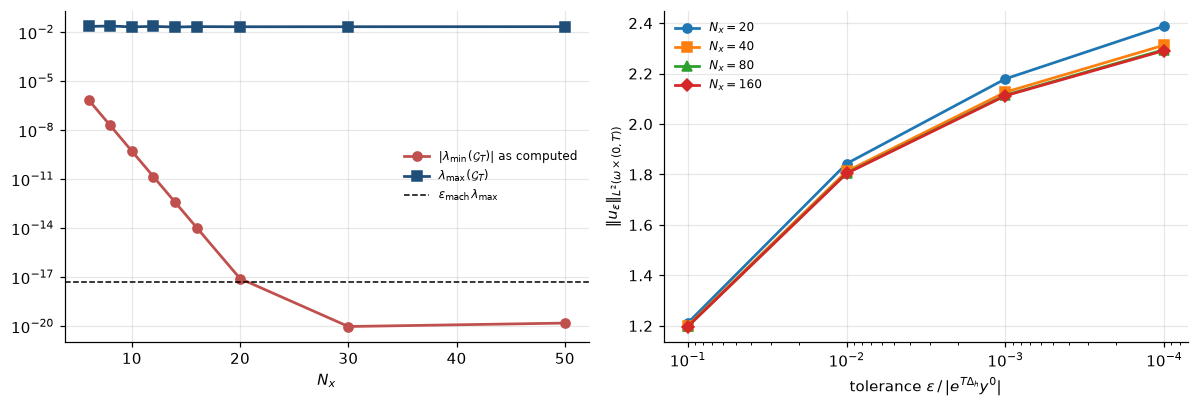

In [4]:
T_heat, omega = 0.1, (0.2, 0.5)


def heat_setup(n_x):
    x, h = heat_grid(n_x)
    mu, V = laplacian_eigen(n_x)
    w = indicator(x, *omega)
    K = heat_gramian_spectral(mu, V, w, T_heat)              # G_T = V K V^T
    d_hat = np.exp(-mu * T_heat) * (V.T @ indicator(x, 0.6, 0.9))   # e^{T Delta_h} y0 in eigen-coordinates
    return x, h, mu, V, w, K, d_hat


def eps_null_control(K, d_hat, h, eps):
    # Minimize 1/2 phi^T K phi + eps |phi|_h + <d, phi>: phi = -(K + m I)^{-1} d with |y(T)|_h = eps.
    lam, W = np.linalg.eigh(K)
    dd = W.T @ d_hat
    residual = lambda log_m: np.sqrt(h) * np.linalg.norm(np.exp(log_m) / (lam + np.exp(log_m)) * dd) - eps
    m_eps = np.exp(brentq(residual, -100, 20, xtol=1e-14))
    phi_hat = -W @ (dd / (lam + m_eps))
    y_T = d_hat + K @ phi_hat
    return phi_hat, np.sqrt(h * phi_hat @ K @ phi_hat), np.sqrt(h) * np.linalg.norm(y_T)


grams = {}
for n_x in (6, 8, 10, 12, 14, 16, 20, 30, 50):
    eig = np.linalg.eigvalsh(heat_setup(n_x)[5])
    grams[n_x] = (eig[0], eig[-1])
print("computed lambda_min, lambda_max of G_T:", {n: (f"{a:.1e}", f"{b:.1e}") for n, (a, b) in grams.items()})

eps_list = [1e-1, 1e-2, 1e-3, 1e-4]
control_norms = {}
for n_x in (20, 40, 80, 160):
    x, h, mu, V, w, K, d_hat = heat_setup(n_x)
    free = np.sqrt(h) * np.linalg.norm(d_hat)                 # |e^{T Delta_h} y0|: doing nothing
    rows = [eps_null_control(K, d_hat, h, e * free) for e in eps_list]
    control_norms[n_x] = [r[1] for r in rows]
    print(f"N_x = {n_x:3d}: ||u_eps|| = {np.round(control_norms[n_x], 4)};  attained |y(T)| / eps = {np.round([r[2] / (e * free) for r, e in zip(rows, eps_list)], 8)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ns = np.array(list(grams))
ax1.semilogy(ns, [abs(grams[n][0]) for n in ns], "o-", color=COLORS["control"], label=r"$|\lambda_{\min}(\mathcal{G}_T)|$ as computed")
ax1.semilogy(ns, [grams[n][1] for n in ns], "s-", color=COLORS["state"], label=r"$\lambda_{\max}(\mathcal{G}_T)$")
ax1.axhline(np.finfo(float).eps * max(g[1] for g in grams.values()), color="black", ls="--", lw=1, label=r"$\varepsilon_{\rm mach}\,\lambda_{\max}$")
ax1.set_xlabel("$N_x$"); ax1.legend(fontsize=8)
for n_x, marker in zip(control_norms, "os^D"):
    ax2.semilogx(eps_list, control_norms[n_x], marker + "-", label=f"$N_x={n_x}$")
ax2.invert_xaxis(); ax2.set_xlabel(r"tolerance $\varepsilon\,/\,|e^{T\Delta_h}y^0|$"); ax2.set_ylabel(r"$\|u_\varepsilon\|_{L^2(\omega\times(0,T))}$")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 3.** The heat equation E4 with $\omega=(0.2,0.5)$, $T=0.1$, $y^0=1_{(0.6,0.9)}$. *Left:* the extreme eigenvalues of the discrete Gramian $\mathcal G_T$ as computed in double precision, against $N_x$. The dashed line is $\varepsilon_{\rm mach}\lambda_{\max}$, the resolution of the computation. *Right:* norm of the $\varepsilon$-control against the tolerance, for $N_x=20,40,80,160$.

*Interpretation (answer to the prediction).* $\lambda_{\max}$ hardly changes. Over the resolved range $N_x\le16$ the computed $\lambda_{\min}(\mathcal G_T)$ deteriorates extremely rapidly (a factor of about 35 per two nodes); from $N_x\approx20$ on it reaches $\varepsilon_{\rm mach}\lambda_{\max}$, can come out negative through rounding (hence the absolute value), and its apparent rate is not numerically trustworthy. **A direct solve of $\mathcal G_T\varphi_T=d$ is numerically unreliable: ill-conditioned in double precision for this discretization and resolution.** This is consistent with $c_{\rm term}=0$, but it is *not* a proof of the infinite-dimensional statements, proved or cited above. The $\varepsilon$-method only inverts $\mathcal G_T+\mu I$ with $\mu$ far above rounding level; each $\varepsilon$ is below $|e^{T\Delta_h}y^0|$, so the printed ratios $|y(T)|/\varepsilon$ equal $1$. On the right, $\|u_\varepsilon\|$ grows as $\varepsilon\to0$ but **levels off**, as the uniform bound $2\sqrt C\|y^0\|$ predicts for a null-controllable system. In this experiment the values for $N_x=20,\dots,160$ agree to within a few percent. That is an observation for this example, not a theorem: discrete observability constants bounded uniformly in $h$ require a proof for each scheme, and we make no such claim.

T = 0.1: ||u|| = 2.2948, |y(T)| = 1.08e-05 (free evolution 1.08e-01);  ||u(t)|| at t = T/10 and t = 0.9 T: 9.161e+00, 3.554e+00
T = 0.5: ||u|| = 0.0262, |y(T)| = 2.08e-07 (free evolution 2.08e-03);  ||u(t)|| at t = T/10 and t = 0.9 T: 2.641e-03, 6.331e-02
T = 1.0: ||u|| = 0.0002, |y(T)| = 1.49e-09 (free evolution 1.49e-05);  ||u(t)|| at t = T/10 and t = 0.9 T: 2.239e-07, 5.246e-04
T = 0.5: |y(T)| recomputed from the state formula: 2.08e-07


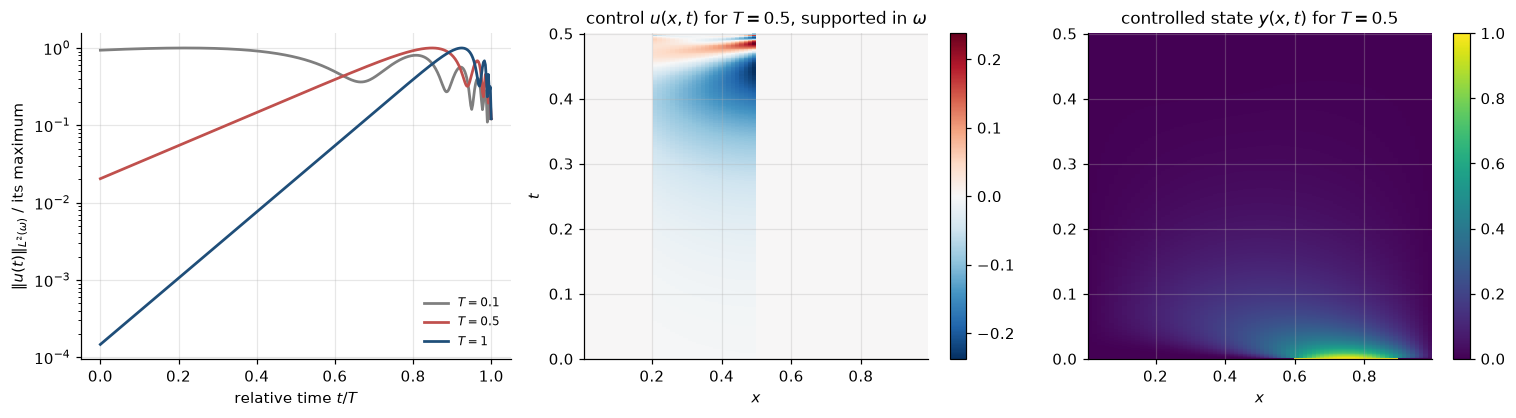

In [5]:
def heat_setup_T(n_x, T_):
    x, h = heat_grid(n_x)
    mu, V = laplacian_eigen(n_x)
    w = indicator(x, *omega)
    K = heat_gramian_spectral(mu, V, w, T_)
    d_hat = np.exp(-mu * T_) * (V.T @ indicator(x, 0.6, 0.9))
    return x, h, mu, V, w, K, d_hat


n_x = 80
profiles = {}
for T_ in (0.1, 0.5, 1.0):                                  # the same eps-method for three horizons
    x, h, mu, V, w, K, d_hat = heat_setup_T(n_x, T_)
    free = np.sqrt(h) * np.linalg.norm(d_hat)
    phi_hat, u_norm, yT_norm = eps_null_control(K, d_hat, h, 1e-4 * free)
    t = np.linspace(0, T_, 401)
    U = np.array([w * (V @ (np.exp(-mu * (T_ - s)) * phi_hat)) for s in t])
    profiles[T_] = (t, np.sqrt(h) * np.linalg.norm(U, axis=1))
    print(f"T = {T_}: ||u|| = {u_norm:.4f}, |y(T)| = {yT_norm:.2e} (free evolution {free:.2e});  "
          f"||u(t)|| at t = T/10 and t = 0.9 T: {profiles[T_][1][40]:.3e}, {profiles[T_][1][360]:.3e}")
    if T_ == 0.5:
        U_show, t_show, phi_show = U, t, phi_hat

# controlled state for T = 0.5 by the exact variation-of-constants formula
x, h, mu, V, w, K, d_hat = heat_setup_T(n_x, 0.5)
M = V.T @ (w[:, None] * V)
S = mu[:, None] + mu[None, :]
y0_hat = V.T @ indicator(x, 0.6, 0.9)
Y = np.array([V @ (np.exp(-mu * s) * y0_hat + (M * (-np.expm1(-S * s)) / S) @ (np.exp(-mu * (0.5 - s)) * phi_show)) for s in t_show])
print(f"T = 0.5: |y(T)| recomputed from the state formula: {np.sqrt(h) * np.linalg.norm(Y[-1]):.2e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
for T_, color in zip(profiles, (COLORS["reference"], COLORS["control"], COLORS["state"])):
    t, un = profiles[T_]
    axes[0].semilogy(t / T_, un / un.max(), color=color, label=f"$T={T_:g}$")
axes[0].set_xlabel("relative time $t/T$"); axes[0].set_ylabel(r"$\|u(t)\|_{L^2(\omega)}$ / its maximum"); axes[0].legend(fontsize=8)
im1 = axes[1].pcolormesh(x, t_show, U_show, shading="auto", cmap="RdBu_r", vmin=-np.abs(U_show).max(), vmax=np.abs(U_show).max())
axes[1].set_xlabel("$x$"); axes[1].set_ylabel("$t$"); axes[1].set_title(r"control $u(x,t)$ for $T=0.5$, supported in $\omega$")
fig.colorbar(im1, ax=axes[1])
im2 = axes[2].pcolormesh(x, t_show, Y, shading="auto", cmap="viridis")
axes[2].set_xlabel("$x$"); axes[2].set_title("controlled state $y(x,t)$ for $T=0.5$")
fig.colorbar(im2, ax=axes[2])
plt.tight_layout(); plt.show()

**Figure 4.** $\varepsilon$-controls for $N_x=80$ and $\varepsilon=10^{-4}|e^{T\Delta_h}y^0|$. *Left:* $\|u(t)\|_{L^2(\omega)}$, normalized by its maximum, against the relative time $t/T$, for the horizons $T=0.1$, $0.5$ and $1$. *Middle:* the control $u(x,t)$ for $T=0.5$, which vanishes outside $\omega=(0.2,0.5)$. *Right:* the controlled state for $T=0.5$, starting from $y^0=1_{(0.6,0.9)}$.

*Interpretation.* For the short horizon $T=0.1$, comparable with the diffusion time $1/\lambda_1=1/\pi^2\approx0.1$, the control works during the whole interval and its size even decreases towards the end. For $T=0.5$ and $T=1$ the control is tiny at first, while the free heat flow does most of the work, and it grows by more than an order of magnitude towards $t=T$. This is the concentration shown on pp. 211 and 215. In all cases the control oscillates in space and time near $t=T$: it is the backward heat equation seen from the final time, whose high frequencies are visible only there. The drop in the last instants is an effect of the regularization: the $\varepsilon$-term removes the highest frequencies of $\varphi_T$, which the exact null control would contain. The printed terminal norms are $10^{-4}$ times those of the free evolution.

## 5. Control ↔ ML
`CORE`

- **Adjoint and backpropagation.** **DIRECT CONNECTION**, made precise in §2: forward pass = state, backward pass = adjoint, gradient = their combination. Its discrete-time version is Exercise 6, and its use for residual networks is [notebook 13](13_resnets_neural_odes.ipynb).
- **The $\varepsilon$-functional.** **MATHEMATICAL ANALOGY.** Approximating a target to tolerance $\varepsilon$ by elements of a dense but non-closed range, with costs that may explode as $\varepsilon\to0$, resembles approximation by neural networks of bounded size ([notebook 12](12_shallow_networks_representation_sparsity.ipynb)). The structures are similar; the spaces and the costs differ.
- **Ill-conditioning.** **FORWARD CONNECTION.** The severe ill-conditioning of $\mathcal G_T$ (Figure 3) is a warning for every gradient method of notebook 06: on discretized PDEs, the number of iterations is governed by a condition number that grows with the resolution.

## 6. Details: existence for the density functional, and a finite-dimensional refinement
`DEEPER LOOK`

**Existence for $J_\varepsilon$ (p. 191).** $J_\varepsilon$ is continuous and convex on a Hilbert space, so by the direct method (notebook 06, DEEPER LOOK §11) it suffices to prove coercivity. We prove
$$
\liminf_{\|v\|\to\infty}\frac{J_\varepsilon(v)}{\|v\|}\ge\varepsilon ,
$$
which gives $J_\varepsilon(v)\ge\tfrac\varepsilon2\|v\|$ for $\|v\|$ large, hence coercivity.

*Proof, by contradiction and subsequences.* Write $\hat v=v/\|v\|$, so that
$$
\frac{J_\varepsilon(v)}{\|v\|}=\tfrac12\|v\|\,\|\mathcal L^*\hat v\|^2+\varepsilon-(f,\hat v).
$$
Suppose the claim fails. Then there are $\delta>0$ and a sequence with $\|v_j\|\to\infty$ and $J_\varepsilon(v_j)/\|v_j\|\le\varepsilon-\delta$ for all $j$.
1. Since $(f,\hat v_j)\le\|f\|$, the identity gives $\tfrac12\|v_j\|\,\|\mathcal L^*\hat v_j\|^2\le\|f\|$, so $\|\mathcal L^*\hat v_j\|\to0$.
2. The sequence $(\hat v_j)$ is bounded, so a subsequence converges weakly, $\hat v_{j_k}\rightharpoonup\hat v$. A bounded linear operator maps weakly convergent sequences to weakly convergent ones, so $\mathcal L^*\hat v_{j_k}\rightharpoonup\mathcal L^*\hat v$. By step 1 the same sequence tends to $0$ in norm, hence $\mathcal L^*\hat v=0$, and $\hat v=0$ by injectivity.
3. Therefore $(f,\hat v_{j_k})\to0$, and the identity gives $\liminf_kJ_\varepsilon(v_{j_k})/\|v_{j_k}\|\ge\varepsilon$, which contradicts $J_\varepsilon(v_{j_k})/\|v_{j_k}\|\le\varepsilon-\delta$. $\square$

The argument applies to *every* unbounded sequence; no case distinction on the size of $\|\mathcal L^*\hat v_j\|$ is needed.

**Approximation with exact finite-dimensional projections (p. 192).** If $E\subset H$ is finite-dimensional with orthogonal projection $\pi_E$, then for every $f$ and $\varepsilon>0$ there is $u$ with $\|\mathcal Lu-f\|\le\varepsilon$ **and** $\pi_ELu=\pi_Ef$. The proof minimizes $J(v)=\tfrac12\|\mathcal L^*v\|^2+\varepsilon\|(I-\pi_E)v\|-(f,v)$ (Lions–Zuazua, 1997; stated here without proof). For control, this means reaching a target approximately while matching finitely many of its moments exactly.

**The $\varepsilon$-algorithm as Tikhonov regularization with a discrepancy rule.** The formula $\tilde v=(\mathcal L\mathcal L^*+\mu I)^{-1}f$ is Tikhonov regularization. The non-squared penalty $\varepsilon\|v\|$ selects the regularization parameter $\mu$ automatically, by requiring the residual to be exactly $\varepsilon$ (when $\|f\|>\varepsilon$). With the squared penalty $\varepsilon\|v\|^2$ (the exercise suggested on p. 190), $\mu$ is fixed in advance and the residual is not controlled directly (Exercise 4).

## 7. Moments, waves and the geometric control condition
`RESEARCH WINDOW`

**Moments and heat asymptotics (pp. 197–200).** The asymptotic behaviour of solutions of the heat equation in $\mathbb R^N$ is determined by the moments of the initial datum and the derivatives of the Gaussian profile (p. 197). A function with vanishing mass can be written as a divergence, $f=\operatorname{div}F$, with estimates on $F$ that are dual to Hardy-type inequalities (pp. 198–199; Duoandikoetxea–Zuazua, 1992). These decompositions quantify how fast heat forgets its initial datum, the same smoothing that rules out exact controllability to arbitrary $L^2$ targets, while approximate and null controllability hold.

**Waves are different (pp. 210, 212, 234).** Controls for the wave equation are oscillatory, whatever the length of the horizon (p. 210), and they do not concentrate at $t=T$. Information travels at finite speed along rays, so a control region $\omega$ works only if every ray of geometric optics enters $\omega$ within time $T$: the **Geometric Control Condition** of Bardos–Lebeau–Rauch (p. 234). When the GCC fails, only weaker properties hold. Discretization is also delicate: finite-difference schemes create spurious high-frequency waves that travel too slowly, and uniform observability can be lost as the mesh is refined (p. 205; Zuazua, *SIAM Review* 2005, p. 41). The commutation "discretize then control = control then discretize" fails there (p. 205).

**Open directions.** Quantitative costs of null control as $T\to0$ or as $\omega$ shrinks; numerical schemes whose discrete observability constants are provably uniform in $h$; control of nonlinear parabolic equations. Turnpike phenomena for heat and waves are the subject of [notebook 08](08_long_time_control_turnpike.ipynb).

## 8. Common misconceptions
`CORE`

**"The adjoint method is an approximation."** It gives the exact gradient of the discrete cost, at the price of two solves. Finite differences are the approximation (Figure 1).

**"Dense range means every target can be reached."** Only approximately, and possibly at an exploding cost (Figure 2). Reaching every target exactly needs a quantitative inequality.

**"If the observation vanishes only for $\varphi=0$, observability holds."** True in finite dimension (notebook 03, p. 97), false for the heat equation. There $c_{\rm term}=0$, while unique continuation holds (§4).

**"Heat controls always concentrate at the final time."** The slides observe this tendency, and in Figure 4 it appears for $T=0.5$ and $T=1$. For $T=0.1$, however, the regularized control acts during the whole interval and decreases near the end. No theorem of this notebook fixes the time profile.

## 9. What you should remember
`CORE`

1. For $J(b)=\tfrac12|x-x^*|^2+\tfrac12|b|^2$ with $Ax=b$: $\nabla J(b)=p+b$ with $A^*p=x-x^*$. Two solves instead of $N+1$, and the adjoint is the Lagrange multiplier of the state equation.
2. The adjoint method is reverse-mode differentiation, the mechanism of backpropagation.
3. Dense range ⟺ injective adjoint. Minimizing $\tfrac12\|\mathcal L^*v\|^2+\varepsilon\|v\|-(f,v)$ gives $u=\mathcal L^*\tilde v$ with $\|\mathcal Lu-f\|\le\varepsilon$, but $\|u\|$ may explode as $\varepsilon\to0$.
4. On a bounded connected domain with $C^2$ boundary, the heat equation is null-controllable from any nonempty open $\omega$ in any time $T>0$ (cited). The minimal-norm control is $u=\bar\varphi1_\omega$, from the HUM functional $J_0$, minimized in the completion for the observation norm. In our longer-horizon examples it concentrates near $t=T$, not in the shortest one.
5. For the heat equation, unique continuation holds but $c_{\rm term}=0$. Only the initial-form inequality (O) holds, and it gives controls bounded uniformly in $\varepsilon$.
6. Discrete heat Gramians are numerically singular already at modest resolution. Use regularized ($\varepsilon$) formulations, and do not read discrete numbers as infinite-dimensional theorems.

## 10. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. `FIRST PASS` exercises are the minimum route; `STANDARD` ones consolidate the notebook; `ADVANCED` ones are optional. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★★ (deriving an adjoint)** · `FIRST PASS`. Let $Ax=b$ as in §1, let $C\in\mathbb R^{k\times N}$ observe the state, $z\in\mathbb R^k$ be a desired observation and $\beta>0$, and set $J(b)=\tfrac12|Cx-z|^2+\tfrac\beta2|b|^2$. (a) Derive the adjoint equation and show that $\nabla J(b)=p+\beta b$ with $A^*p=C^*(Cx-z)$. (b) Recover the same equations from a Lagrangian, as in §2. (c) If $M$ different costs $J_1,\dots,J_M$ of the same state are needed, each with its gradient, how many solves do sensitivities, finite differences and the adjoint method need? When would you prefer sensitivities to adjoints?

**Exercise 2 ★★ (checking a gradient)** · `FIRST PASS`. Implement the gradient of Exercise 1 for the convection–diffusion matrix of Laboratory 1 with $N=100$, $C$ the restriction to the nodes in $(0.4,0.6)$, $z=1$ there, and $\beta=0.1$. Check it with the directional test of Laboratory 1: plot the relative error of the forward difference quotient against $h$, and explain the two regimes. Then introduce a deliberate error (for instance, use $A$ instead of $A^*$ in the adjoint solve) and describe how the test reveals it.

**Exercise 3 ★★ (dense range in finite dimension)** · `STANDARD`. Let $\mathcal L\in\mathbb R^{N\times N}$. (a) Prove that $(\operatorname{Range}\mathcal L)^\perp=\ker \mathcal L^\top$. (b) Deduce that $\mathcal L$ is onto if and only if $\mathcal L^\top$ is injective, and that in finite dimension "dense range" and "onto" coincide. (c) Show that in finite dimension injectivity of $\mathcal L^\top$ implies $\|\mathcal L^\top v\|\ge\alpha\|v\|$ for some $\alpha>0$, and identify the best $\alpha$. Which step fails in infinite dimension?

**Exercise 4 ★★ (the footnote of p. 190: regularized HUM)** · `STANDARD`. Replace $\varepsilon\|v\|$ by $\varepsilon\|v\|^2$: $\tilde J(v)=\tfrac12\|\mathcal L^*v\|^2+\varepsilon\|v\|^2-(f,v)$. (a) Show that $\tilde J$ is coercive *without* any assumption on $\mathcal L$, and find its minimizer. (b) Show that the residual $\mathcal Lu-f$ of $u=\mathcal L^*\tilde v$ equals $-2\varepsilon\tilde v$. Does $\|\mathcal Lu-f\|\le\varepsilon$ hold? (c) In the eigenbasis of $\mathcal L\mathcal L^*$, with eigenvalues $s_j^2$, compute the residual and show that it tends to $0$ as $\varepsilon\to0$ when $\mathcal L^*$ is injective. Why can no rate be given in general?

**Exercise 5 ★★ (the discrete optimality system of heat control)** · `STANDARD`. For the semi-discrete heat equation $y'=\Delta_hy+1_\omega u$, $y(0)=y^0$, derive the optimality system of the problem "minimize $\tfrac12\int_0^T\|u\|_h^2\,dt$ subject to $y(T)=0$" with a Lagrangian, as in §2. Show that the control is $u=1_\omega\varphi$ with $-\varphi'=\Delta_h\varphi$, and that $\varphi_T$ solves $\mathcal G_T\varphi_T=-e^{T\Delta_h}y^0$. Which property of $\Delta_h$ makes the adjoint equation look like the state equation backward in time?

**Exercise 6 ★★★ (a discrete adjoint: backpropagation through time)** · `ADVANCED`. Discretize the heat equation with explicit Euler, $y_{k+1}=(I+\Delta t\,\Delta_h)y_k+\Delta t\,1_\omega u_k$ for $k=0,\dots,K-1$, with $N_x=20$, $T=0.1$ and $\Delta t$ satisfying the stability condition $\Delta t\le h^2/2$. Take the cost $\mathcal J(u_0,\dots,u_{K-1})=\tfrac12\|y_K\|_h^2+\tfrac\beta2\sum_k\Delta t\,\|u_k\|_h^2$ with $\beta=10^{-3}$ and $y^0=1_{(0.6,0.9)}$. (a) Derive the **backward recursion** for adjoint vectors $p_k$ that gives all partial derivatives $\partial\mathcal J/\partial u_k$ in one backward sweep. (b) Implement it, and check one directional derivative against a centred finite difference. (c) Run gradient descent and report $\|y_K\|_h$.

In [6]:
# TODO: student exercise (Exercise 6)
# Write grad_discrete(u) returning (cost, gradient) for the explicit-Euler heat problem,
# using one forward sweep for y_k and one backward sweep for the adjoint vectors p_k.

def grad_discrete(u):
    ...  # your code here
    return None, 0

## Where are we going?
`CORE`

In the optimality system of the minimal-norm heat control the adjoint appears isolated: the cost involves the control only, with a terminal constraint. The slides relate this to the tendency of the control to act near $t=T$ (pp. 212, 216), which our examples showed for the longer horizons. [Notebook 08](08_long_time_control_turnpike.ipynb) adds a cost on the **state** itself. The optimality system then couples state and adjoint in both directions, and over long horizons optimal controls and trajectories spend most of the time near the solution of a **steady** optimal control problem: the turnpike property. The adjoint, the Lagrangian derivation of §2 and the duality of notebook 03 are its tools.

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| §1 Design through a state equation | 165, 193–194 | Shape design; $Ax=b$, $J(b)$, Euler–Lagrange equation |
| §2 Adjoint method | 195–196 | Cost of the OS; adjoint system; $J'(\bar b)=p+\bar b$ |
| §2 Backpropagation | 53 | Reverse-mode automatic differentiation |
| §3 Density | 189–192, 141 | Dense range; Hahn–Banach; $J_\varepsilon$; coercivity; Gaussian filter; $\pi_E$ extension |
| §4 Heat control | 211–216 | Null controllability; $J_0$; observability; concentration at $t=T$; optimality system |
| §4 Unique continuation vs observability | 97 | Equivalence fails in infinite dimension |
| §7 Research window | 197–200, 205, 210, 212, 234, 41 | Moments; waves; GCC; numerics of waves |

The source-map rows also record the pedagogical additions (the Lagrangian derivation and solve counts, Laboratory 1, the computation of the $\varepsilon$-minimizer, Figure 2, the 1-D unique-continuation and non-observability computations, the uniform bound for $\varepsilon$-controls, Laboratory 2 and Figures 3–4) and the remarks on the source slides (pp. 194–196 at every $b$; p. 214 coercivity and notation).